# EmoExpress: AI Image Generation

## Objective

This notebook generates a personalized supportive image using the image
prompt created by the RAG and LLM response-generation pipeline.

The implementation will:

1. Load a previously generated EmoExpress response.
2. Extract its image prompt and encouraging caption.
3. Validate and strengthen the image prompt.
4. Generate an image using the OpenAI image API.
5. Overlay the personalized caption directly onto the image.
6. Save and display the final image with the caption embedded inside it.


Import libraries

In [1]:
from pathlib import Path
from datetime import datetime
import base64
import json
import os
import re
import textwrap
import time

from PIL import Image as PILImage
from PIL import ImageDraw, ImageFont
from IPython.display import Image as NotebookImage
from IPython.display import display
from dotenv import load_dotenv
from openai import OpenAI


Configure paths and API access

In [2]:
PROJECT_ROOT = Path.cwd().parent

GENERATED_RESPONSE_DIR = (PROJECT_ROOT/ "outputs"/ "generated_responses")

GENERATED_IMAGE_DIR = (PROJECT_ROOT/ "outputs"/ "generated_images")

GENERATED_IMAGE_DIR.mkdir(parents=True,exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY was not found in the .env file.")

client = OpenAI(api_key=OPENAI_API_KEY)

# print("Generated response directory:", GENERATED_RESPONSE_DIR)
# print("Generated image directory:", GENERATED_IMAGE_DIR)

Load the output from the LLM Response 

In [3]:
response_path = (GENERATED_RESPONSE_DIR/ "sample_rag_llm_output.json")

if not response_path.exists():
    raise FileNotFoundError("Run 03_RAG_and_LLM_Response_Generation.ipynb first. "
        f"Missing file: {response_path}")

with open(response_path,"r",encoding="utf-8") as file:
    generated_response = json.load(file)

generated_response

{'empathetic_response': "It's completely understandable to feel disappointed after facing multiple rejections. Remember, this journey can be tough, but it doesn't define your capabilities. Each rejection is a step towards finding the right opportunity for you.",
 'recommendations': [{'recommendation': 'Reflect on your applications and interviews to identify areas for improvement.',
   'source_title': 'Tips Job Search',
   'page': 3},
  {'recommendation': 'Celebrate small victories, like perfecting your resume or expanding your network.',
   'source_title': 'Tips Job Search',
   'page': 4},
  {'recommendation': 'Reach out to friends or mentors for support and feedback during your job search.',
   'source_title': 'Stress Resilience',
   'page': 3}],
 'caption': 'Every rejection is a step closer to your dream job.',
 'image_prompt': 'A sunrise over a mountain, symbolizing hope and new beginnings.',
 'retrieval_status': 'grounded',
 'sources': [{'title': 'Tips Job Search', 'page': 3},
  {'

Extract the required fields:

In [4]:
image_prompt = generated_response.get("image_prompt","").strip()

caption = generated_response.get("caption","").strip()

if not image_prompt:
    raise ValueError("The generated response does not contain an image prompt.")

print("IMAGE PROMPT")
print(image_prompt)

print("\nCAPTION")
print(caption)

IMAGE PROMPT
A sunrise over a mountain, symbolizing hope and new beginnings.

CAPTION
Every rejection is a step closer to your dream job.


**Create a safe prompt-enhancement function**

The LLM already generated the main prompt. This function adds consistent visual and safety instructions without changing its meaning.

In [5]:
def prepare_image_prompt(image_prompt):
    """
    Add consistent style and safety requirements to the
    image prompt generated by the LLM.
    """
    if not isinstance(image_prompt, str):
        raise TypeError("image_prompt must be a string.")

    image_prompt = image_prompt.strip()

    if not image_prompt:
        raise ValueError("image_prompt cannot be empty.")

    requirements = """
Create a polished, emotionally supportive digital illustration.

Visual requirements:
- communicate emotional progress, encouragement, and realistic hope;
- use symbolic imagery rather than showing a specific identifiable person;
- use a calm, balanced composition;
- make the scene suitable for an emotional-wellness application;
- do not include words, captions, logos, watermarks, or interface elements;
- do not depict self-harm, violence, graphic distress, medication,
  medical treatment, or clinical diagnosis;
- do not make exaggerated promises that everything is immediately fixed.
""".strip()
    return f"""
MAIN SCENE

{image_prompt}

ADDITIONAL REQUIREMENTS

{requirements}
""".strip()

Prepare the final prompt:

In [6]:
final_image_prompt = prepare_image_prompt(image_prompt)

print(final_image_prompt)

MAIN SCENE

A sunrise over a mountain, symbolizing hope and new beginnings.

ADDITIONAL REQUIREMENTS

Create a polished, emotionally supportive digital illustration.

Visual requirements:
- communicate emotional progress, encouragement, and realistic hope;
- use symbolic imagery rather than showing a specific identifiable person;
- use a calm, balanced composition;
- make the scene suitable for an emotional-wellness application;
- do not include words, captions, logos, watermarks, or interface elements;
- do not depict self-harm, violence, graphic distress, medication,
  medical treatment, or clinical diagnosis;
- do not make exaggerated promises that everything is immediately fixed.


Create a safe filename helper

In [7]:
def create_safe_filename(caption,extension="png"):
    """
    Create a readable filename from the generated caption.
    """

    safe_caption = re.sub(r"[^a-zA-Z0-9]+","_",caption.lower()).strip("_")

    if not safe_caption:
        safe_caption = "emoexpress_image"

    safe_caption = safe_caption[:50]

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S"    )

    return (f"{safe_caption}_{timestamp}.{extension}"    )

Create the image-generation function

In [8]:
IMAGE_MODEL = "gpt-image-2"
IMAGE_SIZE = "1024x1024"
IMAGE_QUALITY = "medium"

In [9]:
def generate_supportive_image(prompt,
                            client,
                            output_directory,
                            caption="",
                            model=IMAGE_MODEL,
                            size=IMAGE_SIZE,
                            quality=IMAGE_QUALITY):
    """
    Generate, decode, and save one supportive image.
    """

    if not prompt or not prompt.strip():
        raise ValueError("A non-empty image prompt is required.")

    start_time = time.perf_counter()

    response = client.images.generate(model=model,
                                    prompt=prompt,
                                    size=size,
                                    quality=quality,
                                    n=1)

    generation_time = (time.perf_counter() - start_time)

    if not response.data:
        raise RuntimeError("The image API returned no image data.")

    encoded_image = response.data[0].b64_json

    if not encoded_image:
        raise RuntimeError("The image response did not contain Base64 data.")

    image_bytes = base64.b64decode(encoded_image)

    file_name = create_safe_filename(caption=caption,extension="png")

    image_path = (Path(output_directory)/ file_name)

    with open(image_path,"wb") as file:
        file.write(image_bytes)

    return {"image_path": str(image_path),
        "model": model,
        "size": size,
        "quality": quality,
        "generation_time_seconds": float(generation_time),
        "prompt": prompt,
        "caption": caption}

**Generate the image**

In [10]:
image_result = generate_supportive_image(prompt=final_image_prompt,
                                        client=client,
                                        output_directory=GENERATED_IMAGE_DIR,
                                        caption=caption)

image_result

{'image_path': 'd:\\FullStack_Academic\\Final Capstone\\EmoExpress\\outputs\\generated_images\\every_rejection_is_a_step_closer_to_your_dream_job_20260813_103807.png',
 'model': 'gpt-image-2',
 'size': '1024x1024',
 'quality': 'medium',
 'generation_time_seconds': 58.36119790000157,
 'prompt': 'MAIN SCENE\n\nA sunrise over a mountain, symbolizing hope and new beginnings.\n\nADDITIONAL REQUIREMENTS\n\nCreate a polished, emotionally supportive digital illustration.\n\nVisual requirements:\n- communicate emotional progress, encouragement, and realistic hope;\n- use symbolic imagery rather than showing a specific identifiable person;\n- use a calm, balanced composition;\n- make the scene suitable for an emotional-wellness application;\n- do not include words, captions, logos, watermarks, or interface elements;\n- do not depict self-harm, violence, graphic distress, medication,\n  medical treatment, or clinical diagnosis;\n- do not make exaggerated promises that everything is immediately fi

## Add the caption directly to the generated image

The image API creates the visual scene first. Pillow is then used to add the
personalized caption as a readable overlay. This keeps the caption exact and
avoids relying on the image model to spell text correctly.


In [11]:
def load_caption_font(font_size):
    """Load a common Windows font, with portable fallbacks."""

    font_candidates = [
        Path("C:/Windows/Fonts/arialbd.ttf"),
        Path("C:/Windows/Fonts/arial.ttf"),
        Path("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"),
    ]

    for font_path in font_candidates:
        if font_path.exists():
            return ImageFont.truetype(
                str(font_path),
                size=font_size,
            )

    return ImageFont.load_default()


def wrap_caption_text(
    draw,
    caption,
    font,
    maximum_width,
):
    """Wrap text according to its rendered pixel width."""

    words = caption.split()

    if not words:
        return ""

    lines = []
    current_line = words[0]

    for word in words[1:]:
        candidate_line = f"{current_line} {word}"

        candidate_box = draw.textbbox(
            (0, 0),
            candidate_line,
            font=font,
        )

        candidate_width = (
            candidate_box[2]
            - candidate_box[0]
        )

        if candidate_width <= maximum_width:
            current_line = candidate_line
        else:
            lines.append(current_line)
            current_line = word

    lines.append(current_line)

    return "\n".join(lines)


def add_caption_to_image(
    image_path,
    caption,
    output_path=None,
):
    """
    Overlay a centered caption near the bottom of an image
    and return the path to the final image.
    """

    if not isinstance(caption, str):
        raise TypeError(
            "caption must be a string."
        )

    caption = caption.strip()

    if not caption:
        raise ValueError(
            "caption cannot be empty."
        )

    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Generated image was not found: {image_path}"
        )

    if output_path is None:
        output_path = image_path.with_name(
            f"{image_path.stem}_with_caption.png"
        )
    else:
        output_path = Path(output_path)

    image = PILImage.open(
        image_path
    ).convert("RGBA")

    image_width, image_height = image.size

    font_size = max(
        28,
        int(image_width * 0.045),
    )

    font = load_caption_font(
        font_size
    )

    overlay = PILImage.new(
        "RGBA",
        image.size,
        (0, 0, 0, 0),
    )

    draw = ImageDraw.Draw(
        overlay
    )

    horizontal_padding = int(
        image_width * 0.08
    )

    maximum_text_width = (
        image_width
        - 2 * horizontal_padding
    )

    wrapped_caption = wrap_caption_text(
        draw=draw,
        caption=caption,
        font=font,
        maximum_width=maximum_text_width,
    )

    text_box = draw.multiline_textbbox(
        (0, 0),
        wrapped_caption,
        font=font,
        spacing=10,
        align="center",
        stroke_width=2,
    )

    text_width = (
        text_box[2]
        - text_box[0]
    )

    text_height = (
        text_box[3]
        - text_box[1]
    )

    vertical_padding = max(
        24,
        int(image_height * 0.025),
    )

    banner_height = (
        text_height
        + 2 * vertical_padding
    )

    banner_top = (
        image_height
        - banner_height
        - int(image_height * 0.035)
    )

    banner_left = int(
        image_width * 0.045
    )

    banner_right = (
        image_width
        - banner_left
    )

    banner_bottom = (
        banner_top
        + banner_height
    )

    draw.rounded_rectangle(
        [
            banner_left,
            banner_top,
            banner_right,
            banner_bottom,
        ],
        radius=28,
        fill=(0, 0, 0, 175),
    )

    text_x = (
        image_width
        - text_width
    ) / 2

    text_y = (
        banner_top
        + vertical_padding
        - text_box[1]
    )

    draw.multiline_text(
        (text_x, text_y),
        wrapped_caption,
        font=font,
        fill=(255, 255, 255, 255),
        spacing=10,
        align="center",
        stroke_width=2,
        stroke_fill=(0, 0, 0, 220),
    )

    final_image = PILImage.alpha_composite(
        image,
        overlay,
    ).convert("RGB")

    final_image.save(
        output_path,
        format="PNG",
        quality=95,
    )

    return str(output_path)


In [12]:
final_image_path = add_caption_to_image(
    image_path=image_result["image_path"],
    caption=image_result["caption"],
)

image_result[
    "original_image_path"
] = image_result["image_path"]

image_result[
    "final_image_path"
] = final_image_path

print(
    "Final image with embedded caption:",
    final_image_path,
)


Final image with embedded caption: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\generated_images\every_rejection_is_a_step_closer_to_your_dream_job_20260813_103807_with_caption.png


Display the result

Caption:
Every rejection is a step closer to your dream job.

Generation time: 58.36 seconds

Original generated image: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\generated_images\every_rejection_is_a_step_closer_to_your_dream_job_20260813_103807.png
Final image with caption: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\generated_images\every_rejection_is_a_step_closer_to_your_dream_job_20260813_103807_with_caption.png


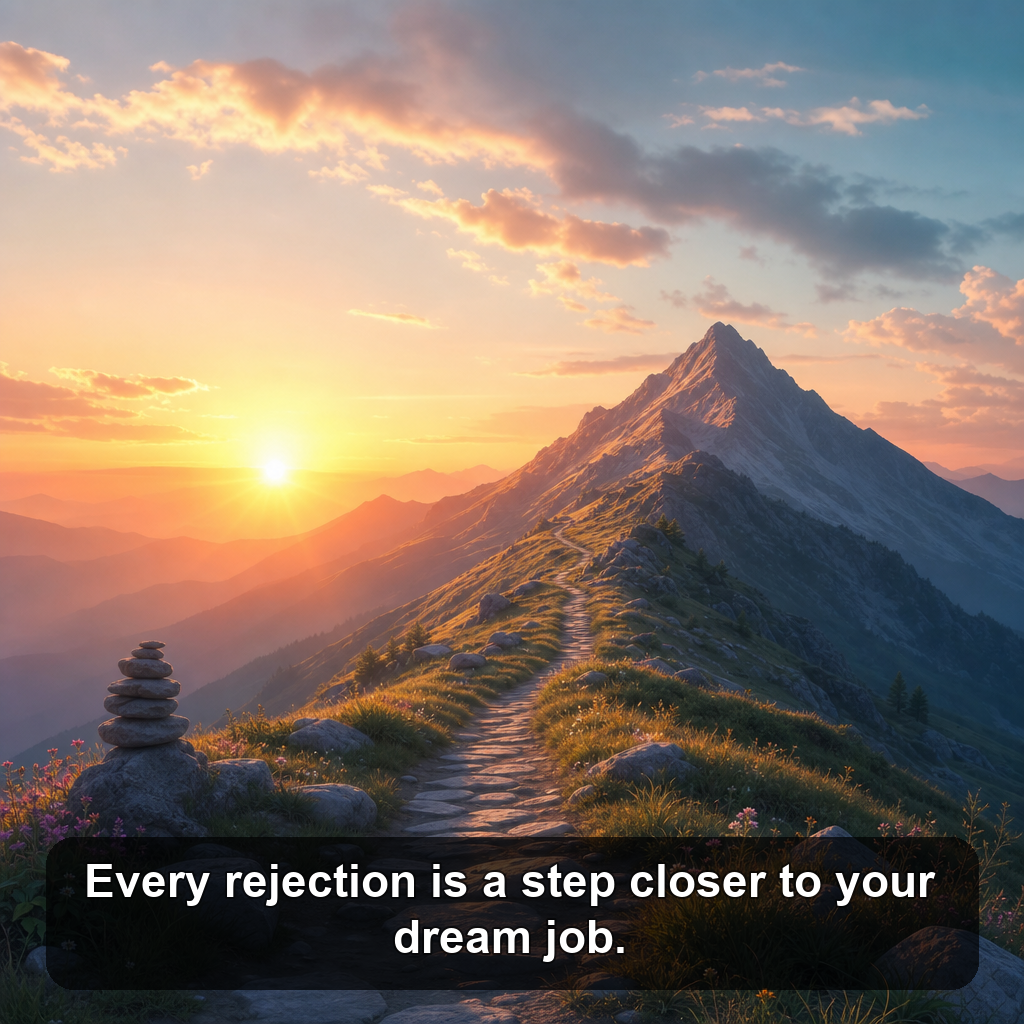

In [13]:
print("Caption:")
print(image_result["caption"])

print(
    "\nGeneration time:",
    round(
        image_result["generation_time_seconds"],
        2,
    ),
    "seconds",
)

print(
    "\nOriginal generated image:",
    image_result["original_image_path"],
)

print(
    "Final image with caption:",
    image_result["final_image_path"],
)

display(
    NotebookImage(
        filename=image_result["final_image_path"],
        width=700,
    )
)


Save the image metadata

In [14]:
image_metadata_path = Path(
    image_result["final_image_path"]
).with_suffix(".json")

with open(
    image_metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        image_result,
        file,
        ensure_ascii=False,
        indent=4,
    )

print(
    "Saved image metadata:",
    image_metadata_path,
)


Saved image metadata: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\generated_images\every_rejection_is_a_step_closer_to_your_dream_job_20260813_103807_with_caption.json


Add the image information to the full response

In [15]:
complete_emoexpress_output = (
    generated_response.copy()
)

complete_emoexpress_output[
    "generated_image"
] = {
    "original_path": image_result[
        "original_image_path"
    ],
    "final_path": image_result[
        "final_image_path"
    ],
    "caption_embedded": True,
    "model": image_result["model"],
    "size": image_result["size"],
    "quality": image_result["quality"],
    "generation_time_seconds": (
        image_result[
            "generation_time_seconds"
        ]
    ),
}


Save the complete result:

In [16]:
complete_output_path = (GENERATED_IMAGE_DIR/ "complete_emoexpress_example.json")

with open(complete_output_path,"w",encoding="utf-8") as file:
    json.dump(complete_emoexpress_output,file,ensure_ascii=False,indent=4)

# print("Saved complete output:",complete_output_path)

*Add error handling for the application*

In [17]:
def generate_image_safely(
    prompt,
    client,
    output_directory,
    caption="",
):
    """
    Generate an image, embed its caption, and prevent an image
    failure from stopping the rest of the EmoExpress pipeline.
    """

    try:
        result = generate_supportive_image(
            prompt=prompt,
            client=client,
            output_directory=output_directory,
            caption=caption,
        )

        result[
            "original_image_path"
        ] = result["image_path"]

        result[
            "final_image_path"
        ] = add_caption_to_image(
            image_path=result[
                "original_image_path"
            ],
            caption=caption,
        )

        result["status"] = "success"
        result["caption_embedded"] = True
        result["error"] = None

        return result

    except Exception as error:
        return {
            "image_path": None,
            "original_image_path": None,
            "final_image_path": None,
            "model": IMAGE_MODEL,
            "size": IMAGE_SIZE,
            "quality": IMAGE_QUALITY,
            "generation_time_seconds": None,
            "prompt": prompt,
            "caption": caption,
            "caption_embedded": False,
            "status": "failed",
            "error": str(error),
        }


# Conclusion

This notebook implemented the AI image-generation component of
EmoExpress and produced a complete final visual containing the
personalized caption directly inside the image.

The image prompt and caption generated by the grounded LLM pipeline were
loaded from the previous notebook. The OpenAI image model first created
the supportive visual scene. Pillow was then used to wrap, center, and
overlay the exact caption on a semi-transparent banner near the bottom
of the image.

Both the original image and the final captioned image were saved. The
saved metadata now records the original path, final path, model,
dimensions, quality setting, generation time, and whether the caption
was successfully embedded.

This approach separates visual generation from text rendering, which
improves caption accuracy and produces a final artifact that can be
displayed directly in the Streamlit application.
